# Purpose

This script is used to apply the 8 timseries cross-validation models to the the test data (for 2022). 

In [12]:
#high level modules
import os
import imp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# custom modules
this_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/"

imp.load_source("universals", os.path.join(this_dir, "universal_functions.py"))
from universals import load_pickle_file, twotemp_labels_features_test, predict_2_values_test, return_test_error_metrics

imp.load_source("vis", os.path.join(this_dir, "vis_functions.py"))
from vis import ts_plot, create_scatter_plot_test

We need to read in the transformed test data, apply the models, and save the resictions.

In [14]:
# import test data
file_path = os.path.expanduser("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/")

test_fn = os.path.join(file_path, "test.csv")
with open(test_fn) as f:
    test = pd.read_csv(f, sep=',')

And we need to filter this for our target date - Jul 1 through Sept 11.

In [15]:
# arrange the data by date
test['date'] = pd.to_datetime(test['date'])
test = test.sort_values(by='date')
#test = test.loc[test['date'].between('2022-07-01', '2022-09-11')]

Now we need to apply the models to the test data, but first we need to format the data for the models

In [16]:
test_features, test_labels = twotemp_labels_features_test(test)
test_features.shape, test_labels.shape

((219, 28), (219, 2))

Load the models

In [17]:
# load the models
model_dir = '/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/dump/three_ten/'

models = [f for f in os.listdir(model_dir) if 'history' not in f]
models.sort()

model_1 = load_pickle_file(models[0], model_dir)
model_2 = load_pickle_file(models[1], model_dir)
model_3 = load_pickle_file(models[2], model_dir)
model_4 = load_pickle_file(models[3], model_dir)


Now we need to apply the models to the test data and get the resictions, for which we also need the standarization parameters to back calculate.

In [18]:
transform = pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/data/mu_sigma.csv", index_col=0)

t_mean_1m = transform['mean'].get('z_1m')
t_std_1m = transform['sd'].get('z_1m')

t_mean_05m = transform['mean'].get('z_int')
t_std_05m = transform['sd'].get('z_int')

test["pred_1m_1"], test["pred_05m_1"] = predict_2_values_test(model_1, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_2"], test["pred_05m_2"] = predict_2_values_test(model_2, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_3"], test["pred_05m_3"] = predict_2_values_test(model_3, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_4"], test["pred_05m_4"] = predict_2_values_test(model_4, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)


And now, let's make the ensemble prediction to assess the model performance.

In [19]:
test["ts_cv_ensemble_pred_1m"] = np.mean(test[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4']], axis=1)
test["ts_cv_ensemble_pred_05m"] = np.mean(test[['pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']], axis=1)

In order to compare these with the actual values, we need to load the actual values and calculate the performance metrics. To do this, we will back-calculate using the mean and standard deviation.

In [21]:
test['mean_1m_temp_degC'] = test['mean_1m_temp_degC'] * t_std_1m + t_mean_1m
test['mean_0_5m_temp_degC'] = test['mean_0_5m_temp_degC'] * t_std_05m + t_mean_05m

Let's look at the data from 1m first:

In [22]:
return_test_error_metrics(test["mean_1m_temp_degC"], test["ts_cv_ensemble_pred_1m"])

Test Datset Error Metrics:
Mean Squared Error: 0.038194681153550784
Mean Absolute Error: 0.15898000761323153
Root Mean Squared Error: 0.1954345955903171
Mean Absolute Percentage Error: 0.390791873622306


(0.038194681153550784,
 0.15898000761323153,
 0.1954345955903171,
 0.390791873622306)

And then the data from 0-5m:

In [23]:
return_test_error_metrics(test["mean_0_5m_temp_degC"], test["ts_cv_ensemble_pred_05m"])

Test Datset Error Metrics:
Mean Squared Error: 0.02951615149589227
Mean Absolute Error: 0.133944910825244
Root Mean Squared Error: 0.17180265276151085
Mean Absolute Percentage Error: 0.6082114729456053


(0.02951615149589227,
 0.133944910825244,
 0.17180265276151085,
 0.6082114729456053)


Let's look at the error metrics for the models:

**1m results - in forecast mode**

Mean Squared Error: 0.25

Mean Absolute Error: 0.40

Root Mean Squared Error: 0.50

Mean Absolute Percentage Error: 2.89

**1m baseline**

Mean Squared Error for 1m baseline: 0.23

Mean Absolute Error for 1m baseline: 0.38

MAPE: 2.46%


**0-5m results - in forecast mode**

Mean Squared Error: 0.22

Mean Absolute Error: 0.37

Root Mean Squared Error: 0.47

Mean Absolute Percentage Error: 3.18%

**0-5m baseline**

Mean Squared Error for 0-5m baseline : 0.11

Mean Absolute Error for 0-5m baseline : 0.28

MAPE: 2.09%

And also during the regulatory period:

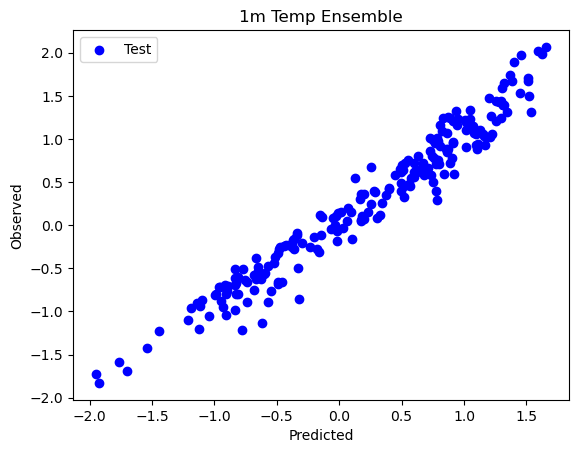

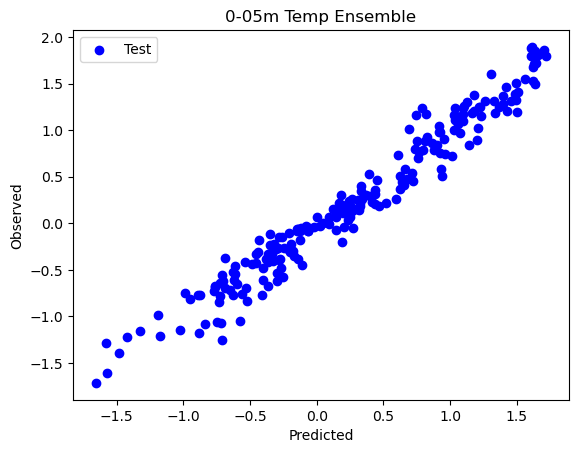

In [27]:
create_scatter_plot_test("1m Temp Ensemble", test["ts_cv_ensemble_pred_1m"], test["mean_1m_temp_degC"])
create_scatter_plot_test("0-05m Temp Ensemble", test["ts_cv_ensemble_pred_05m"], test["mean_0_5m_temp_degC"])

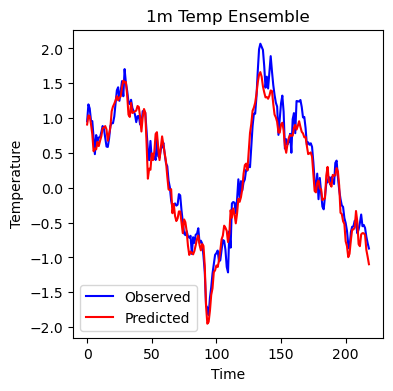

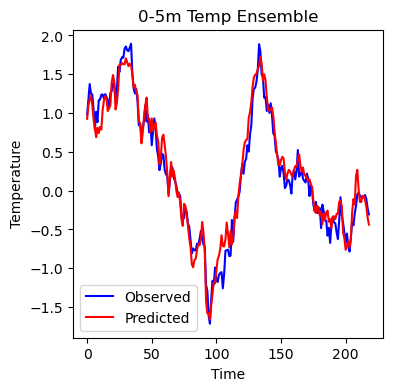

In [28]:
ts_plot(test["mean_1m_temp_degC"], test["ts_cv_ensemble_pred_1m"], "1m Temp Ensemble")
ts_plot(test["mean_0_5m_temp_degC"], test["ts_cv_ensemble_pred_05m"], "0-5m Temp Ensemble")


In [32]:
# Ensure 'date' is a datetime column
test['date'] = pd.to_datetime(test['date'])

# Extract unique years
years = test['date'].dt.year.unique()


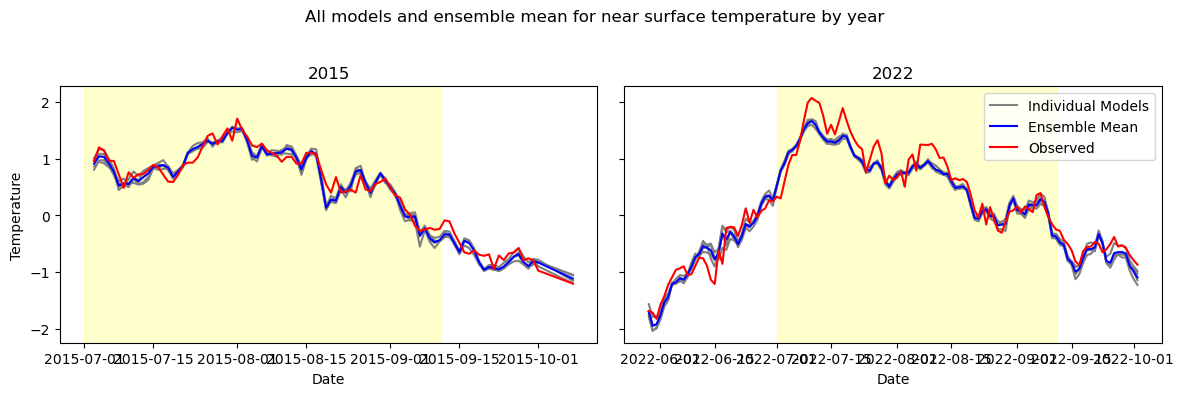

In [36]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_4"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["ts_cv_ensemble_pred_1m"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["mean_1m_temp_degC"], label="Observed", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for near surface temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

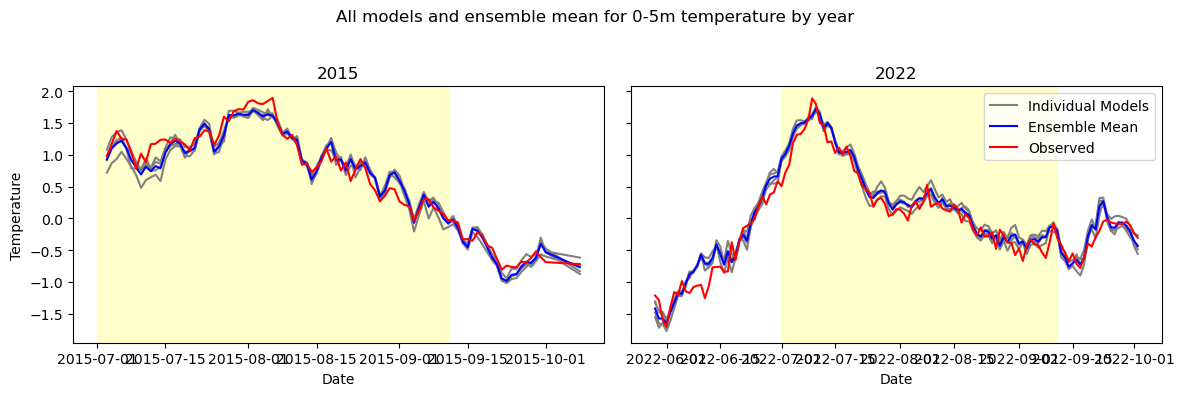

In [39]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]
    
for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_4"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["ts_cv_ensemble_pred_05m"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["mean_0_5m_temp_degC"], label="Observed", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for 0-5m temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

These actually look quite good. While the model doesn't capture the highest values at 1m, there were zero instances in the training/validation set with values that high, so it's not surprising that the model doesn't capture them. The model does a good job of capturing the general trends in the data and does very well with the high 0-5m values.


## Create timeseries residual plot

Calculate residuals

In [40]:
test['res_1m_1'] = (test['pred_1m_1']) - (test['mean_1m_temp_degC'])
test['res_1m_2'] = (test['pred_1m_2']) - (test['mean_1m_temp_degC'])
test['res_1m_3'] = (test['pred_1m_3']) - (test['mean_1m_temp_degC'])
test['res_1m_4'] = (test['pred_1m_4']) - (test['mean_1m_temp_degC'])
test['res_1m_ensemble'] = (test['ts_cv_ensemble_pred_1m']) - (test['mean_1m_temp_degC'])

test['res_05m_1'] = test['pred_05m_1'] - test['mean_0_5m_temp_degC']
test['res_05m_2'] = test['pred_05m_2'] - test['mean_0_5m_temp_degC']
test['res_05m_3'] = test['pred_05m_3'] - test['mean_0_5m_temp_degC']
test['res_05m_4'] = test['pred_05m_4'] - test['mean_0_5m_temp_degC']
test['res_05m_ensemble'] = test['ts_cv_ensemble_pred_05m'] - test['mean_0_5m_temp_degC']


In [41]:
yit = test.filter(['mean_0_5m_temp_degC', 'mean_1m_temp_degC'])
yit = yit.shift(periods=1).rename(columns={'mean_0_5m_temp_degC': 'yit_mean_0_5m_temp_degC', 
                                     'mean_1m_temp_degC': 'yit_mean_1m_temp_degC'})

test = pd.concat([test, yit], axis=1)
test['res_yit_0_5m'] = test['yit_mean_0_5m_temp_degC'] - test['mean_0_5m_temp_degC']
test['res_yit_1m'] = np.sqrt(test['yit_mean_1m_temp_degC']) - np.sqrt(test['mean_1m_temp_degC'])


/Users/steeleb/miniconda3/envs/env_TLS_DSS/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


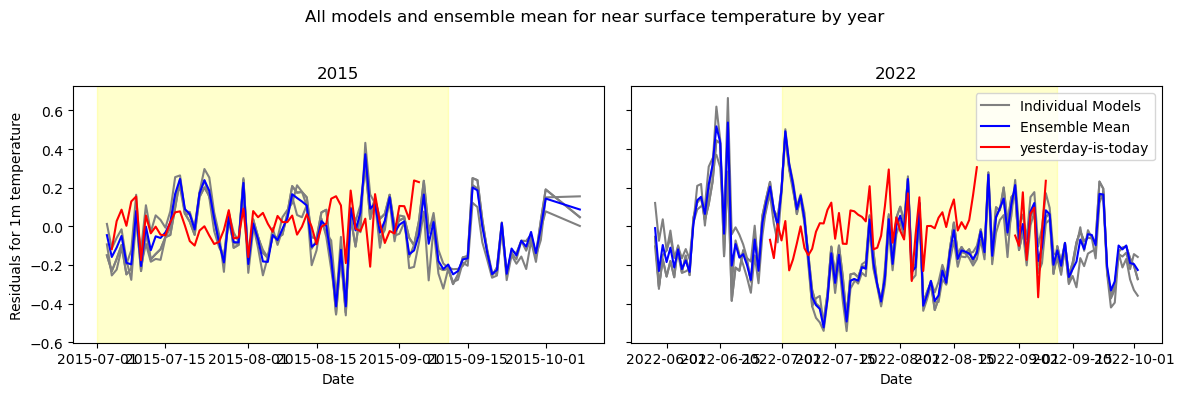

In [48]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]
    
for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["res_1m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_1"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_ensemble"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["res_yit_1m"], label="yesterday-is-today", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Residuals for 1m temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for near surface temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


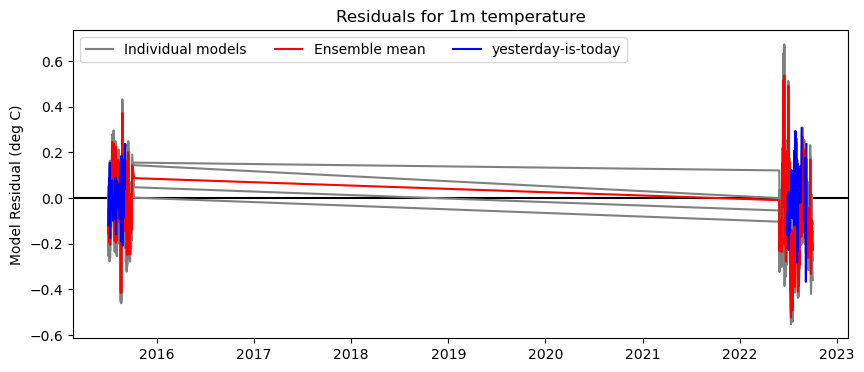

In [ ]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]
    
for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["res_05m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_1"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_ensemble"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["res_yit_0_5m"], label="yesterday-is-today", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Residuals for 0-5m temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for 0-5m temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()